In [1]:
import os
import sys
from allium_cepa_classifier import PROJECT_ROOT
from allium_cepa_classifier.config import AlliumCepaConfig
from allium_cepa_classifier.models.allium_cepa_model import AlliumCepaModel

In [5]:
print(PROJECT_ROOT)

/home/nicolas/Documentos/UTN/INA/allium_cepa_automation


In [2]:
config = AlliumCepaConfig()
model = AlliumCepaModel(config)

In [3]:
# image = "datasets/allium_cepa_full_images_merged/test/images/004_00011.jpg"
# image = '/home/nicolas/Documentos/UTN/INA/allium-cepa-classifier/datasets/allium_cepa_full_images_merged/train/images/A_14.png'
image = "datasets/allium_cepa_full_images_merged/test/images"

In [6]:
result = model.predict(PROJECT_ROOT / image)


0: 640x640 17 cells, 2.5ms
Speed: 4.2ms preprocess, 2.5ms inference, 9.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x480 60 cells, 28.7ms
Speed: 1.2ms preprocess, 28.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 19 cells, 30.0ms
Speed: 0.8ms preprocess, 30.0ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 640x640 15 cells, 2.2ms
Speed: 0.7ms preprocess, 2.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 27 cells, 1.9ms
Speed: 0.8ms preprocess, 1.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x480 64 cells, 2.3ms
Speed: 1.1ms preprocess, 2.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

0: 448x640 160 cells, 29.2ms
Speed: 1.3ms preprocess, 29.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 108 cells, 2.5ms
Speed: 1.1ms preprocess, 2.5ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


In [7]:
result.detections.head()

,x_min,y_min,x_max,y_max,confidence,class_id,class_name,image,mitosis,mitosis_score
0,154,227,182,269,0.949365,0,cell,---------Mitotic-cell-division-stages-of-Alliu...,False,0.001059
1,232,149,256,180,0.945119,0,cell,---------Mitotic-cell-division-stages-of-Alliu...,False,0.000028
2,108,272,138,309,0.942990,0,cell,---------Mitotic-cell-division-stages-of-Alliu...,False,0.000012
3,280,168,304,198,0.939601,0,cell,---------Mitotic-cell-division-stages-of-Alliu...,False,0.000204
4,196,122,218,154,0.939426,0,cell,---------Mitotic-cell-division-stages-of-Alliu...,False,0.000111


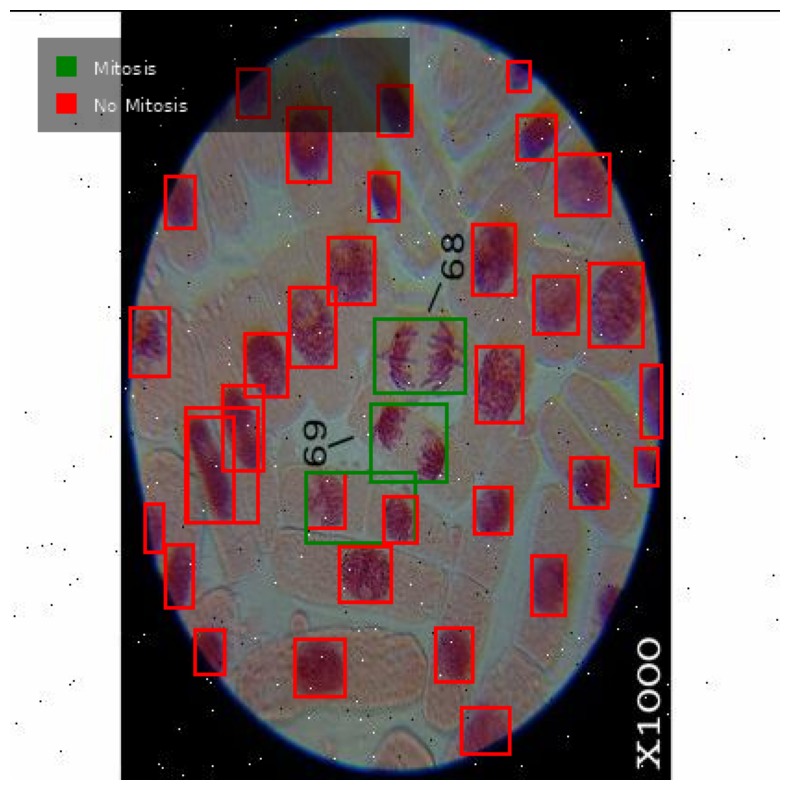

In [9]:
import matplotlib.pyplot as plt

img_to_plot = result.show_annotated(
    image_name='---------Mitotic-cell-division-stages-of-Allium-cepa-L--051_jpg.rf.205eb613f5ff9b48fdfb99982f71c3ce.jpg',
    line_width=2,
)

plt.figure(figsize=(12, 10))

# Show image
plt.imshow(img_to_plot)
plt.axis("off")
plt.show()

In [10]:
t = result.timing
print(f"Detection:      {t['detection_total_s']:.3f}s")
print(f"Classification: {t['classification_total_s']:.3f}s")
print(f"Total:          {t['total_s']:.3f}s")

# Per-image breakdown (useful for directory batches)
for img, secs in t['detection_per_image_s'].items():
    print(f"  {img}: {secs:.3f}s")

Detection:      3.414s
Classification: 6.744s
Total:          10.158s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--120_jpg.rf.09d40a0a4ef51a296b8b638be8b0a311.jpg: 0.397s
  A_209.png: 0.058s
  D_45.png: 0.055s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--018_jpg.rf.b7cdad982a8be4f03ea5d463e4c600d0.jpg: 0.006s
  306132426_377409957762252_6500231601284401131_n_jpg.rf.a7194ce45469cce22b39e129ec049856.jpg: 0.006s
  A_5.png: 0.026s
  004_00042.jpg: 0.074s
  004_00127.jpg: 0.043s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--058_jpg.rf.1dac06c4af8dfa7ab92416e4309d934d.jpg: 0.007s
  B_1.png: 0.022s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--094_jpg.rf.133c973d547096b1609403a2160d9a57.jpg: 0.006s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--034_jpg.rf.a069782ea996e6e3546b7b4b4a13fa46.jpg: 0.006s
  ---------Mitotic-cell-division-stages-of-Allium-cepa-L--038_jpg.rf.72f833eabb4d39f0d168946e9189d0d2.jpg: 0.006s
  A_46.png: 0.022s
  

In [11]:
len(result.detections)

5888

In [12]:
result.get_counts()

{'total_cells': 5888,
 'mitotic_cells': 928,
 'non_mitotic_cells': 4960,
 'mitotic_index': 0.15760869565217392}